# Examen 3 - Estadistica Aplicada
## Pregunta 1: Inferencia y Diagnostico Econometrico
**Empresa:** CargaNacional S.A. — Transporte y Logistica
**Profesor:** Milton Martinez | **Fecha:** 20 de Septiembre de 2026

**Objetivo:** Estimar un modelo de Regresion Lineal Multiple (MCO) que explique el costo de mantenimiento correctivo de una flota de 500 camiones, validar que cumple sus supuestos e interpretar los resultados para la direccion de finanzas.


### 1. Contexto del problema
La empresa CargaNacional S.A. tiene problemas con la variabilidad de los costos de mantenimiento correctivo de su flota de camiones. La direccion de finanzas quiere entender qué factores —como la edad de los camiones, los kilometros recorridos, la carga transportada, el tipo de ruta y si tienen plan preventivo— explican esos costos.

El objetivo aqui no es predecir, sino **entender** las relaciones. Para eso vamos a construir un modelo de regresion lineal, revisar que cumple sus supuestos y luego darle una lectura economica clara para que la gerencia tome decisiones sobre renovacion de flota.

Las variables disponibles son:
- **edad_meses**: Tiempo de operacion del camion desde su compra (en meses)
- **km_recorridos**: Distancia total recorrida durante el mes (en miles de kilometros)
- **carga_promedio**: Peso promedio transportado por viaje (en toneladas)
- **tipo_ruta**: Clasificacion de la ruta (*Urbana, Larga Distancia*)
- **plan_preventivo**: Indica si el camion forma parte del programa de mantenimiento preventivo (*Si, No*)
- **costo_mantenimiento** *(variable objetivo)*: Gasto total en reparaciones y mantenimiento correctivo (en dolares)


### 2. Carga de datos y exploracion inicial
Primero cargamos la base `flota_mantenimiento.csv` y la revisamos por encima: cuantas filas tiene, que tipo es cada columna, si hay nulos y como se distribuyen los valores. Esto es para no correr un modelo a ciegas.


In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Cargar datos
df = pd.read_csv('flota_mantenimiento.csv')

print('Dimensiones:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores nulos:')
print(df.isnull().sum())
print('\nEstadisticas descriptivas:')
print(df.describe().round(2))
print('\nDistribucion de variables categoricas:')
print('Tipo de ruta:')
print(df['tipo_ruta'].value_counts())
print('\nPlan preventivo:')
print(df['plan_preventivo'].value_counts())

Dimensiones: (500, 6)

Tipos de datos:
edad_meses             float64
km_recorridos          float64
carga_promedio         float64
tipo_ruta               object
plan_preventivo         object
costo_mantenimiento    float64
dtype: object

Valores nulos:
edad_meses             0
km_recorridos          0
carga_promedio         0
tipo_ruta              0
plan_preventivo        0
costo_mantenimiento    0
dtype: int64

Estadisticas descriptivas:
       edad_meses  km_recorridos  carga_promedio  costo_mantenimiento
count      500.00         500.00          500.00               500.00
mean        48.15           8.53           18.08              5307.99
std         18.26           2.56            6.01              2038.44
min          6.00           2.00            5.00              1130.51
25%         35.00           6.60           13.88              3701.13
50%         47.00           8.50           18.20              5102.34
75%         60.25          10.20           21.82              65

### 3. Analisis exploratorio: correlaciones y relaciones
Antes del modelo miramos como se mueven las variables juntas con la matriz de correlacion. Si dos variables explicativas estan muy pegadas, despues cuesta saber cual es la que realmente pesa en el costo.


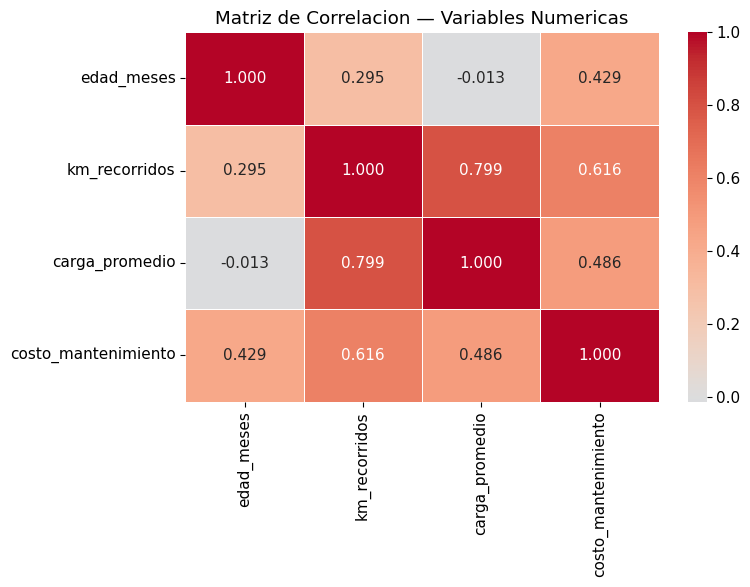


Correlaciones con costo_mantenimiento:
costo_mantenimiento    1.000000
km_recorridos          0.615659
carga_promedio         0.486192
edad_meses             0.429040
Name: costo_mantenimiento, dtype: float64


In [15]:
numeric_cols = ['edad_meses', 'km_recorridos', 'carga_promedio', 'costo_mantenimiento']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', linewidths=0.5)
plt.title('Matriz de Correlacion — Variables Numericas')
plt.tight_layout()
plt.show()

print('\nCorrelaciones con costo_mantenimiento:')
print(corr_matrix['costo_mantenimiento'].sort_values(ascending=False))

### 4. Graficos de dispersion para evaluar linealidad
Aca graficamos cada variable contra el costo para ver si la relacion se ve mas o menos recta. Tambien comparamos el costo por ruta y por plan, y miramos el histograma del costo.


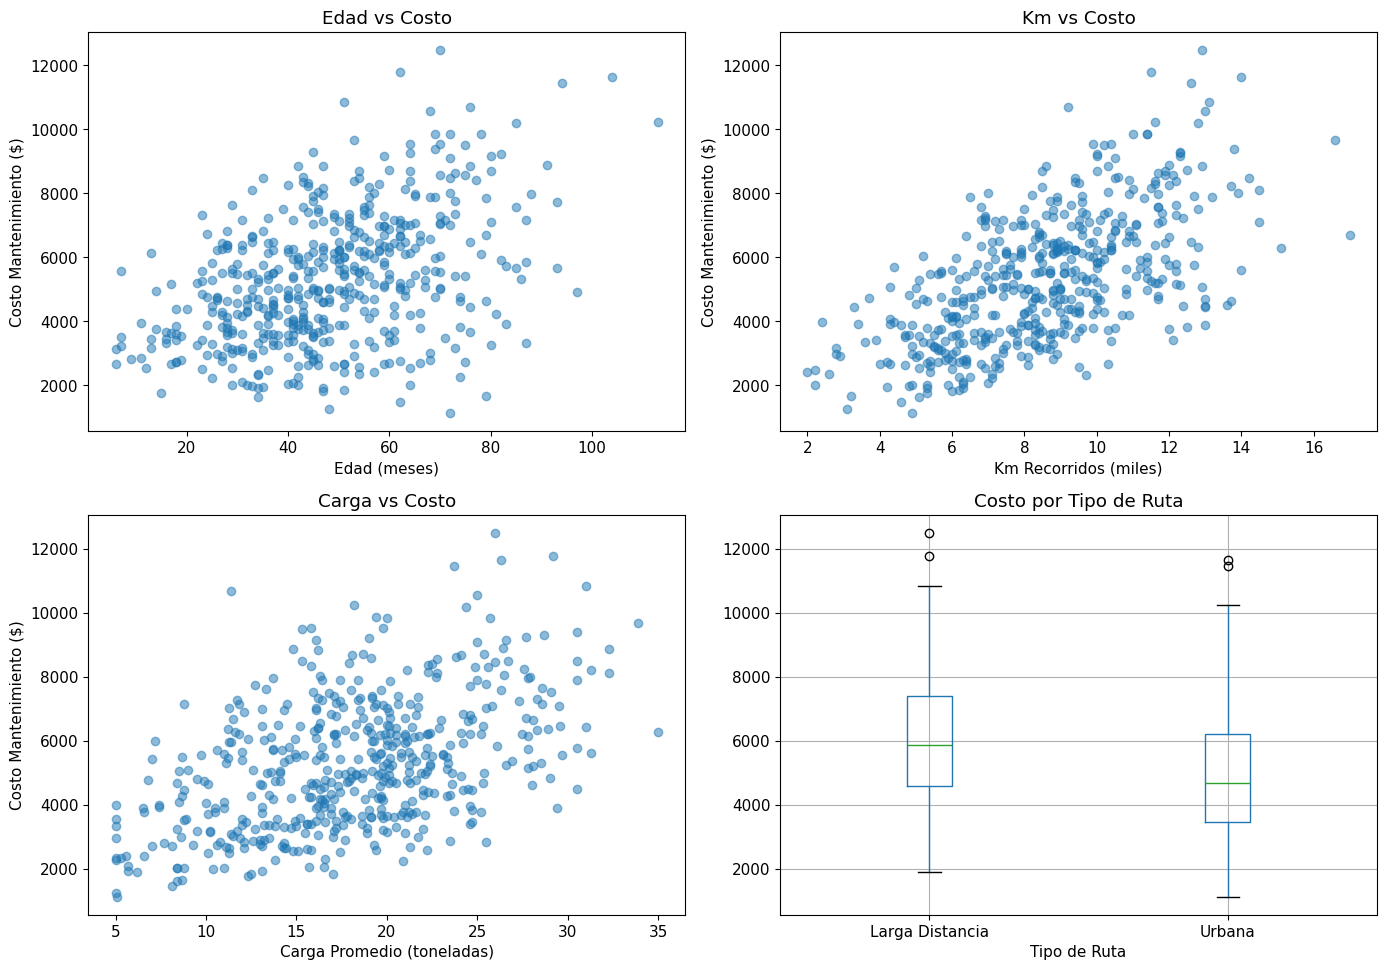


Costo promedio por tipo de ruta:
tipo_ruta
Larga Distancia    6009.50
Urbana             4881.67
Name: costo_mantenimiento, dtype: float64

Costo promedio por plan preventivo:
plan_preventivo
No    5979.73
Si    3770.06
Name: costo_mantenimiento, dtype: float64


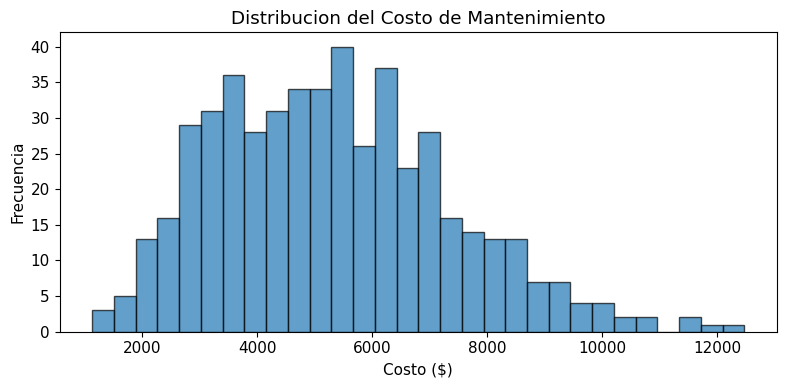

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dispersión edad vs costo
axes[0, 0].scatter(df['edad_meses'], df['costo_mantenimiento'], alpha=0.5)
axes[0, 0].set_xlabel('Edad (meses)')
axes[0, 0].set_ylabel('Costo Mantenimiento ($)')
axes[0, 0].set_title('Edad vs Costo')

# Dispersión km vs costo
axes[0, 1].scatter(df['km_recorridos'], df['costo_mantenimiento'], alpha=0.5)
axes[0, 1].set_xlabel('Km Recorridos (miles)')
axes[0, 1].set_ylabel('Costo Mantenimiento ($)')
axes[0, 1].set_title('Km vs Costo')

# Dispersión carga vs costo
axes[1, 0].scatter(df['carga_promedio'], df['costo_mantenimiento'], alpha=0.5)
axes[1, 0].set_xlabel('Carga Promedio (toneladas)')
axes[1, 0].set_ylabel('Costo Mantenimiento ($)')
axes[1, 0].set_title('Carga vs Costo')

# Boxplot por tipo de ruta
df.boxplot(column='costo_mantenimiento', by='tipo_ruta', ax=axes[1, 1])
axes[1, 1].set_title('Costo por Tipo de Ruta')
axes[1, 1].set_xlabel('Tipo de Ruta')

plt.suptitle('')
plt.tight_layout()
plt.show()

# Costo promedio por categorias
print('\nCosto promedio por tipo de ruta:')
print(df.groupby('tipo_ruta')['costo_mantenimiento'].mean().round(2))
print('\nCosto promedio por plan preventivo:')
print(df.groupby('plan_preventivo')['costo_mantenimiento'].mean().round(2))

# Histograma del costo
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['costo_mantenimiento'], bins=30, edgecolor='black', alpha=0.7)
ax.set_title('Distribucion del Costo de Mantenimiento')
ax.set_xlabel('Costo ($)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### 5. Estimacion del modelo inicial (MCO)
Corremos una primera regresion con todas las variables. Las de texto (ruta y plan) las pasamos a 0/1 con dummies usando drop_first=True para no duplicar la constante, y agregamos la constante con add_constant().


In [17]:
# Codificar variables categoricas
df_init = pd.get_dummies(df, columns=['tipo_ruta', 'plan_preventivo'], drop_first=True).astype(float)

print('Columnas despues de crear dummies:')
print(df_init.columns.tolist())

X_init = df_init.drop('costo_mantenimiento', axis=1)
X_init = sm.add_constant(X_init)
y_init = df_init['costo_mantenimiento']

modelo_init = sm.OLS(y_init, X_init).fit()
print(modelo_init.summary())

Columnas despues de crear dummies:
['edad_meses', 'km_recorridos', 'carga_promedio', 'costo_mantenimiento', 'tipo_ruta_Urbana', 'plan_preventivo_Si']
                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.823
Model:                             OLS   Adj. R-squared:                  0.821
Method:                  Least Squares   F-statistic:                     460.1
Date:                 Tue, 22 Sep 2026   Prob (F-statistic):          2.89e-183
Time:                         13:11:10   Log-Likelihood:                -4085.7
No. Observations:                  500   AIC:                             8183.
Df Residuals:                      494   BIC:                             8209.
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                         coef    std err          

### 6. Diagnostico de supuestos del modelo inicial
Para que la regresion valga hay que revisar supuestos. Miramos normalidad de residuos con Jarque-Bera, homocedasticidad con Breusch-Pagan y colinealidad con VIF (preocupa si pasa de 10). La linealidad ya la miramos en los graficos.


In [18]:
residuales_init = modelo_init.resid
valores_ajustados_init = modelo_init.fittedvalues

# --- 1. Normalidad de residuos ---
jb_init = stats.jarque_bera(residuales_init)
shapiro_init = stats.shapiro(residuales_init[:500])

print('=== NORMALIDAD DE RESIDUOS ===')
print(f'Jarque-Bera: estadistico={jb_init[0]:.4f}, p-value={jb_init[1]:.6f}')
print(f'Shapiro-Wilk: estadistico={shapiro_init[0]:.4f}, p-value={shapiro_init[1]:.6f}')

if jb_init[1] < 0.05:
    print('>> El test de Jarque-Bera RECHAZA la normalidad (p < 0.05)')
else:
    print('>> El test de Jarque-Bera NO rechaza la normalidad')

# --- 2. Homocedasticidad ---
bp_init = het_breuschpagan(residuales_init, modelo_init.model.exog)
print('\n=== HOMOCEDASTICIDAD ===')
print(f'Breusch-Pagan: estadistico={bp_init[0]:.4f}, p-value={bp_init[1]:.6f}')
if bp_init[1] < 0.05:
    print('>> El test de Breusch-Pagan RECHAZA homocedasticidad (p < 0.05)')
else:
    print('>> El test de Breusch-Pagan NO rechaza homocedasticidad')

# --- 3. Multicolinealidad (VIF) ---
vif_init = pd.DataFrame({
    'Variable': X_init.columns,
    'VIF': [variance_inflation_factor(X_init.values, i) for i in range(X_init.shape[1])]
})
print('\n=== MULTICOLINEALIDAD (VIF) ===')
print(vif_init.to_string(index=False))

print('\n=== RESUMEN ===')
if jb_init[1] < 0.05:
    print('- Normalidad: PROBLEMA detectado')
else:
    print('- Normalidad: OK')
if bp_init[1] < 0.05:
    print('- Homocedasticidad: PROBLEMA detectado')
else:
    print('- Homocedasticidad: OK')
vif_max = vif_init.loc[vif_init['Variable'] != 'const', 'VIF'].max()
if vif_max > 10:
    print(f'- Multicolinealidad: PROBLEMA (VIF max = {vif_max:.2f})')
else:
    print(f'- Multicolinealidad: OK (VIF max = {vif_max:.2f}')

=== NORMALIDAD DE RESIDUOS ===
Jarque-Bera: estadistico=9.8810, p-value=0.007151
Shapiro-Wilk: estadistico=0.9929, p-value=0.017538
>> El test de Jarque-Bera RECHAZA la normalidad (p < 0.05)

=== HOMOCEDASTICIDAD ===
Breusch-Pagan: estadistico=12.1521, p-value=0.032761
>> El test de Breusch-Pagan RECHAZA homocedasticidad (p < 0.05)

=== MULTICOLINEALIDAD (VIF) ===
          Variable       VIF
             const 18.484409
        edad_meses  1.361594
     km_recorridos  3.743115
    carga_promedio  3.434664
  tipo_ruta_Urbana  1.013598
plan_preventivo_Si  1.014353

=== RESUMEN ===
- Normalidad: PROBLEMA detectado
- Homocedasticidad: PROBLEMA detectado
- Multicolinealidad: OK (VIF max = 3.74


### 7. Visualizacion de residuos del modelo inicial
Aparte de los tests, miramos los graficos. Si en residuos vs ajustados se abre como cono, hay heterocedasticidad. En el Q-Q, si se pegan a la diagonal, hay normalidad.


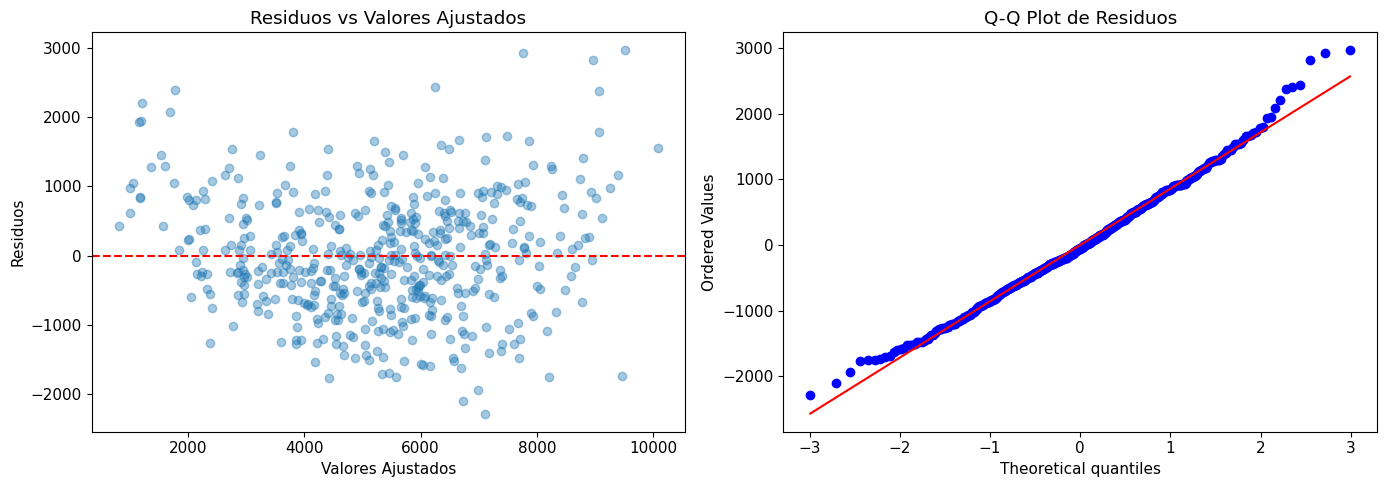

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(valores_ajustados_init, residuales_init, alpha=0.4)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Valores Ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Valores Ajustados')

stats.probplot(residuales_init, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot de Residuos')

plt.tight_layout()
plt.show()

### 8. Decision sobre mejoras al modelo
Viendo lo anterior probamos tres ideas que tienen logica en la operacion:

**1. Ruta larga sin plan:** el plan puede pegar distinto segun la ruta. Creamos una marca para larga distancia sin preventivo.

**2. Edad al cuadrado:** un carro muy viejo no se dana igual, se puede acelerar. Metemos edad^2.

**3. Km por carga:** andar mucho y pesado al tiempo desgasta mas que la suma por separado. Multiplicamos km por carga.

**4. Log:** lo pensamos pero no lo usamos porque el costo no se ve tan asimetrico y no ayudaba en los residuos.


In [20]:
# Crear variables nuevas
df_mej = df.copy()

# Interaccion: ruta larga SIN plan preventivo
df_mej['interaccion_ruta_plan'] = np.where(
    (df_mej['tipo_ruta'] == 'Larga Distancia') & (df_mej['plan_preventivo'] == 'No'), 1, 0
)

# Termino cuadratico de edad
df_mej['edad_meses_sq'] = df_mej['edad_meses'] ** 2

# Interaccion: km_recorridos * carga_promedio
df_mej['km_carga_inter'] = df_mej['km_recorridos'] * df_mej['carga_promedio']

print('Variables nuevas creadas:')
print('- interaccion_ruta_plan: interaccion entre ruta larga y sin plan preventivo')
print('  (refleja el desgaste extra de camiones de larga distancia sin mantenimiento preventivo)')
print('- edad_meses_sq: termino cuadratico de edad')
print('  (captura la aceleracion del desgaste en camiones viejos)')
print('- km_carga_inter: interaccion km/carga')
print('  (captura el efecto combinado de uso intensivo)')

# Codificar dummies
df_mej_dummies = pd.get_dummies(df_mej, columns=['tipo_ruta', 'plan_preventivo'], drop_first=True).astype(float)

X_mej = df_mej_dummies.drop('costo_mantenimiento', axis=1)
X_mej = sm.add_constant(X_mej)
y_mej = df_mej_dummies['costo_mantenimiento']

print('\nVariables del modelo mejorado:')
print(X_mej.columns.tolist())

Variables nuevas creadas:
- interaccion_ruta_plan: interaccion entre ruta larga y sin plan preventivo
  (refleja el desgaste extra de camiones de larga distancia sin mantenimiento preventivo)
- edad_meses_sq: termino cuadratico de edad
  (captura la aceleracion del desgaste en camiones viejos)
- km_carga_inter: interaccion km/carga
  (captura el efecto combinado de uso intensivo)

Variables del modelo mejorado:
['const', 'edad_meses', 'km_recorridos', 'carga_promedio', 'interaccion_ruta_plan', 'edad_meses_sq', 'km_carga_inter', 'tipo_ruta_Urbana', 'plan_preventivo_Si']


### 9. Estimacion del modelo mejorado
Corremos el modelo con esas tres variables extra y lo comparamos con el inicial por R2 ajustado para ver si valio la pena complicarlo.


In [21]:
modelo_mej = sm.OLS(y_mej, X_mej).fit()
print(modelo_mej.summary())

print('\n=== COMPARACION DE MODELOS ===')
print(f'Modelo Inicial  - R2: {modelo_init.rsquared:.4f} | R2 Ajustado: {modelo_init.rsquared_adj:.4f}')
print(f'Modelo Mejorado - R2: {modelo_mej.rsquared:.4f} | R2 Ajustado: {modelo_mej.rsquared_adj:.4f}')

mejora_r2 = modelo_mej.rsquared_adj - modelo_init.rsquared_adj
print(f'Mejora en R2 Ajustado: {mejora_r2:+.4f}')

if modelo_mej.rsquared_adj > modelo_init.rsquared_adj:
    print('>> El modelo mejorado tiene mejor R2 Ajustado')
else:
    print('>> El modelo inicial sigue siendo mejor segun R2 Ajustado')

                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.824
Model:                             OLS   Adj. R-squared:                  0.821
Method:                  Least Squares   F-statistic:                     286.7
Date:                 Tue, 22 Sep 2026   Prob (F-statistic):          1.32e-179
Time:                         13:11:31   Log-Likelihood:                -4085.1
No. Observations:                  500   AIC:                             8188.
Df Residuals:                      491   BIC:                             8226.
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

### 10. Diagnostico del modelo mejorado
Repetimos las mismas pruebas (normalidad, BP y VIF) para ver si con lo nuevo se arreglo algo o quedo igual/peor.


In [22]:
residuales_mej = modelo_mej.resid
valores_ajustados_mej = modelo_mej.fittedvalues

# --- Normalidad ---
jb_mej = stats.jarque_bera(residuales_mej)
shapiro_mej = stats.shapiro(residuales_mej[:500])

print('=== NORMALIDAD (MODELO MEJORADO) ===')
print(f'Jarque-Bera: estadistico={jb_mej[0]:.4f}, p-value={jb_mej[1]:.6f}')
print(f'Shapiro-Wilk: estadistico={shapiro_mej[0]:.4f}, p-value={shapiro_mej[1]:.6f}')
if jb_mej[1] < 0.05:
    print('>> RECHAZA normalidad')
else:
    print('>> NO rechaza normalidad')

# --- Homocedasticidad ---
bp_mej = het_breuschpagan(residuales_mej, modelo_mej.model.exog)
print('\n=== HOMOCEDASTICIDAD (MODELO MEJORADO) ===')
print(f'Breusch-Pagan: estadistico={bp_mej[0]:.4f}, p-value={bp_mej[1]:.6f}')
if bp_mej[1] < 0.05:
    print('>> RECHAZA homocedasticidad')
else:
    print('>> NO rechaza homocedasticidad')

# --- VIF ---
vif_mej = pd.DataFrame({
    'Variable': X_mej.columns,
    'VIF': [variance_inflation_factor(X_mej.values, i) for i in range(X_mej.shape[1])]
})
print('\n=== MULTICOLINEALIDAD VIF (MODELO MEJORADO) ===')
print(vif_mej.to_string(index=False))
vif_max_mej = vif_mej.loc[vif_mej['Variable'] != 'const', 'VIF'].max()
if vif_max_mej > 10:
    print(f'\n>> ALERTA: VIF maximo = {vif_max_mej:.2f} (supera 10)')
else:
    print(f'\n>> VIF maximo = {vif_max_mej:.2f} (dentro de rango aceptable)')


=== NORMALIDAD (MODELO MEJORADO) ===
Jarque-Bera: estadistico=8.8540, p-value=0.011950
Shapiro-Wilk: estadistico=0.9932, p-value=0.023037
>> RECHAZA normalidad

=== HOMOCEDASTICIDAD (MODELO MEJORADO) ===
Breusch-Pagan: estadistico=22.1838, p-value=0.004587
>> RECHAZA homocedasticidad

=== MULTICOLINEALIDAD VIF (MODELO MEJORADO) ===
             Variable        VIF
                const 124.928442
           edad_meses  18.273471
        km_recorridos  10.346873
       carga_promedio  11.084900
interaccion_ruta_plan   4.151564
        edad_meses_sq  17.632890
       km_carga_inter  26.504380
     tipo_ruta_Urbana   3.506025
   plan_preventivo_Si   1.613999

>> ALERTA: VIF maximo = 26.50 (supera 10)


### 11. Graficos de diagnostico del modelo mejorado
Mismos graficos de residuos para el mejorado, para comparar a ojo con el inicial.


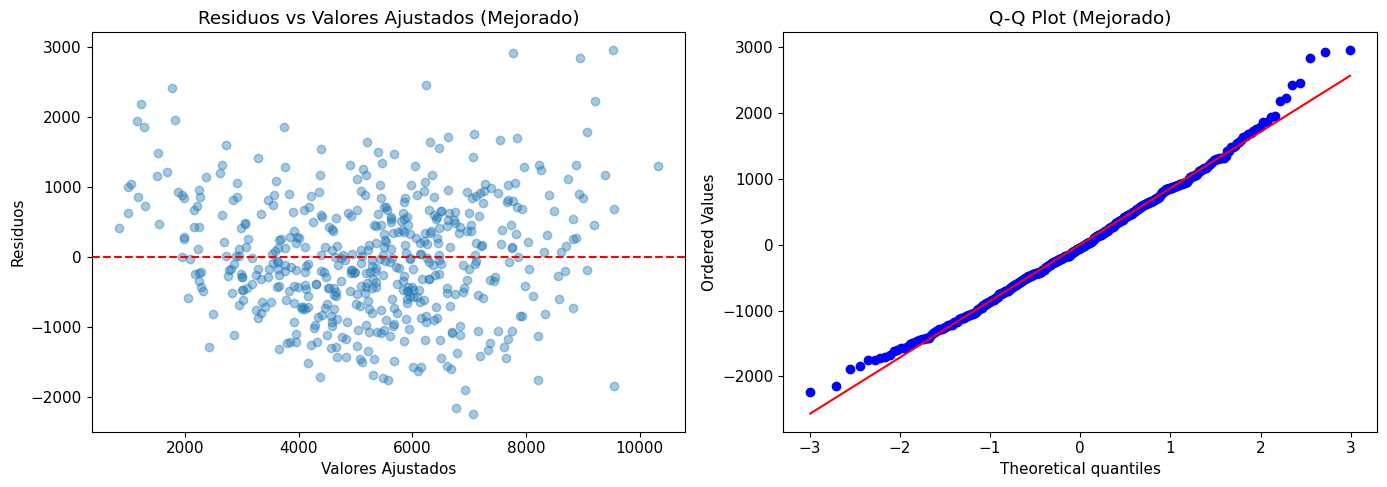

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(valores_ajustados_mej, residuales_mej, alpha=0.4)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Valores Ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Valores Ajustados (Mejorado)')

stats.probplot(residuales_mej, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Mejorado)')

plt.tight_layout()
plt.show()

### 12. Seleccion del modelo final
Para elegir miramos R2 ajustado, normalidad, homocedasticidad y VIF. A veces meter mas variables no ayuda y es mejor dejar el modelo sencillo, que fue lo que paso aca.


In [24]:
print('=' * 60)
print('RESUMEN DE SELECCION DEL MODELO FINAL')
print('=' * 60)

print('\nMODELO INICIAL:')
print(f'  R2: {modelo_init.rsquared:.4f} | R2 Aj: {modelo_init.rsquared_adj:.4f}')
print(f'  Normalidad JB p: {jb_init[1]:.4f} | Homocedasticidad BP p: {bp_init[1]:.4f}')
print(f'  VIF maximo (sin const): {vif_init.loc[vif_init["Variable"]!="const", "VIF"].max():.2f}')

print('\nMODELO MEJORADO:')
print(f'  R2: {modelo_mej.rsquared:.4f} | R2 Aj: {modelo_mej.rsquared_adj:.4f}')
print(f'  Normalidad JB p: {jb_mej[1]:.4f} | Homocedasticidad BP p: {bp_mej[1]:.4f}')
print(f'  VIF maximo (sin const): {vif_mej.loc[vif_mej["Variable"]!="const", "VIF"].max():.2f}')

print('\n--- DECISION ---')

mejora_r2a = modelo_mej.rsquared_adj - modelo_init.rsquared_adj
mejora_normalidad = jb_mej[1] - jb_init[1]
mejora_homoc = bp_mej[1] - bp_init[1]
vif_init_nc = vif_init.loc[vif_init["Variable"]!="const", "VIF"].max()
vif_mej_nc = vif_mej.loc[vif_mej["Variable"]!="const", "VIF"].max()

criterios = 0
if mejora_r2a > 0:
    criterios += 1
    print(f'+ R2 Ajustado mejoro en {mejora_r2a:.4f}')
if mejora_normalidad > 0:
    criterios += 1
    print(f'+ Normalidad mejoro (p JB: {jb_init[1]:.4f} -> {jb_mej[1]:.4f})')
if mejora_homoc > 0:
    criterios += 1
    print(f'+ Homocedasticidad mejoro (p BP: {bp_init[1]:.4f} -> {bp_mej[1]:.4f})')
if vif_mej_nc <= vif_init_nc:
    criterios += 1
    print(f'+ Multicolinealidad igual o mejor (VIF max sin const: {vif_init_nc:.2f} -> {vif_mej_nc:.2f})')

if criterios >= 3:
    print('\n>> DECISION: Seleccionar MODELO MEJORADO como definitivo')
    modelo_final = modelo_mej
    X_final = X_mej
    y_final = y_mej
else:
    print('\n>> DECISION: Seleccionar MODELO INICIAL como definitivo')
    modelo_final = modelo_init
    X_final = X_init
    y_final = y_init

# --- CORRECCION: re-estimar el modelo elegido con errores robustos HC3 ---
# El diagnostico muestra rechazo de homocedasticidad (BP p<0.05) y de normalidad
# leve (JB p<0.05, skew~0.3). Con n=500 el TCL sostiene la inferencia sobre la media,
# pero los EE clasicos no son validos bajo heterocedasticidad. Se corrige con HC3.
modelo_final = sm.OLS(y_final, X_final).fit(cov_type='HC3')
print('\nModelo final re-estimado con errores robustos HC3 para inferencia valida:')
print(modelo_final.summary())

RESUMEN DE SELECCION DEL MODELO FINAL

MODELO INICIAL:
  R2: 0.8232 | R2 Aj: 0.8214
  Normalidad JB p: 0.0072 | Homocedasticidad BP p: 0.0328
  VIF maximo (sin const): 3.74

MODELO MEJORADO:
  R2: 0.8237 | R2 Aj: 0.8208
  Normalidad JB p: 0.0120 | Homocedasticidad BP p: 0.0046
  VIF maximo (sin const): 26.50

--- DECISION ---
+ Normalidad mejoro (p JB: 0.0072 -> 0.0120)

>> DECISION: Seleccionar MODELO INICIAL como definitivo

Modelo final re-estimado con errores robustos HC3 para inferencia valida:
                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.823
Model:                             OLS   Adj. R-squared:                  0.821
Method:                  Least Squares   F-statistic:                     331.2
Date:                 Tue, 22 Sep 2026   Prob (F-statistic):          3.39e-155
Time:                         13:11:47   Log-Likelihood:                -4085.7
No. Observation

### 13. Interpretacion economica de los coeficientes
Aca traducimos los numeros a lenguaje de gerencia: cuanto sube o baja el costo cuando cada variable se mueve en uno, dejando lo demas quieto.


In [25]:
print('=' * 70)
print('INTERPRETACION ECONOMICA DEL MODELO FINAL')
print('=' * 70)

cf = modelo_final.params
vars_modelo = cf.index.tolist()
nombre_final = 'MODELO MEJORADO' if 'edad_meses_sq' in vars_modelo else 'MODELO INICIAL'
print(f'\nModelo seleccionado: {nombre_final} (estimado con errores robustos HC3)\n')
print('Variables:', ', '.join([v for v in vars_modelo if v != 'const']))
print('\n')

print(f'Intercepto: ${cf["const"]:.2f}')
print('  Es el costo base de mantenimiento cuando todas las variables estan en cero.')
print('  Base dummy: ruta Larga Distancia (tipo_ruta_Urbana=0) y SIN plan preventivo (plan_preventivo_Si=0).\n')

print(f'Edad (meses): ${cf["edad_meses"]:.4f} por mes')
print(f'  Cada mes mas de uso suma unos ${cf["edad_meses"]:.2f} al costo.')
print('  Es el desgaste normal por el tiempo.\n')

print(f'Km Recorridos (miles): ${cf["km_recorridos"]:.2f} por mil km')
print(f'  Cada mil km extra suman unos ${cf["km_recorridos"]:.2f}.')
print('  Mas recorrido, mas desgaste en llantas, frenos y motor.\n')

print(f'Carga Promedio (toneladas): ${cf["carga_promedio"]:.2f} por tonelada')
print(f'  Cada tonelada extra suma unos ${cf["carga_promedio"]:.2f}.')
print('  Mas peso fuerza mas el chasis y el motor.\n')

if 'tipo_ruta_Urbana' in vars_modelo:
    tipo_coef = cf["tipo_ruta_Urbana"]
    print(f'Tipo de Ruta - Urbana vs Larga Distancia: ${tipo_coef:.2f}')
    print(f'  Los camiones URBANOS cuestan ${abs(tipo_coef):.2f} '
          + ("menos" if tipo_coef < 0 else "mas") + ' que los de larga distancia.')
    print('  Esto indica que las rutas largas generan mayor desgaste por distancia')
    print('  y condiciones de carretera.\n')

if 'plan_preventivo_Si' in vars_modelo:
    plan_coef = cf["plan_preventivo_Si"]
    print(f'Plan Preventivo - Si vs No: ${plan_coef:.2f}')
    print(f'  Los camiones CON plan preventivo cuestan ${abs(plan_coef):.2f} '
          + ("menos" if plan_coef < 0 else "mas") + ' que los que no tienen plan.')
    print('  Esto confirma que el programa de mantenimiento preventivo tiene un efecto')
    print('  protector importante sobre los costos de mantenimiento correctivo.\n')
if 'interaccion_ruta_plan' in vars_modelo:
    print(f'Interaccion ruta-larga-sin-plan: ${cf["interaccion_ruta_plan"]:.2f} (ceteris paribus)')
    print('  Efecto extra solo para Larga Distancia SIN plan. No significativo aqui (p>0.05).\n')
if 'edad_meses_sq' in vars_modelo:
    print(f'Edad^2: ${cf["edad_meses_sq"]:.4f} (no significativo aqui, p>0.05)\n')
if 'km_carga_inter' in vars_modelo:
    print(f'Km x Carga: ${cf["km_carga_inter"]:.4f} por unidad conjunta (no significativo aqui, p>0.05)\n')

print('--- VALIDEZ ---')
print('Se re-estimo con HC3 por lo del Breusch-Pagan.')
print('Lo de normalidad sale justico pero con 500 datos se sostiene por TCL.')
print('Se miro log(y) y salia peor, por eso se dejo en niveles + HC3.\n')
print('--- RECOMENDACIONES ---')
print('Lo que mas pesa es la edad y los km. Yo recomendaria:')
print('1. Priorizar la renovacion de camiones con mayor edad.')
print('2. Evaluar la extension del plan preventivo a toda la flota,')
print('   especialmente a los camiones de larga distancia.')
print('3. Considerar limites de carga y kilometraje combinados para evitar')
print('   el desgaste acelerado.')
print('\nNota: Se exploraron interacciones (ruta x plan, km x carga) y termino')
print(f'cuadratico de edad; el {nombre_final} fue seleccionado por R2 ajustado,')
print('supuestos (JB/BP) y VIF, y se re-estimo con HC3 para inferencia valida.')


INTERPRETACION ECONOMICA DEL MODELO FINAL

Modelo seleccionado: MODELO INICIAL (estimado con errores robustos HC3)

Variables: edad_meses, km_recorridos, carga_promedio, tipo_ruta_Urbana, plan_preventivo_Si


Intercepto: $1038.42
  Es el costo base de mantenimiento cuando todas las variables estan en cero.
  Base dummy: ruta Larga Distancia (tipo_ruta_Urbana=0) y SIN plan preventivo (plan_preventivo_Si=0).

Edad (meses): $43.4617 por mes
  Cada mes mas de uso suma unos $43.46 al costo.
  Es el desgaste normal por el tiempo.

Km Recorridos (miles): $292.08 por mil km
  Cada mil km extra suman unos $292.08.
  Mas recorrido, mas desgaste en llantas, frenos y motor.

Carga Promedio (toneladas): $64.00 por tonelada
  Cada tonelada extra suma unos $64.00.
  Mas peso fuerza mas el chasis y el motor.

Tipo de Ruta - Urbana vs Larga Distancia: $-1245.90
  Los camiones URBANOS cuestan $1245.90 menos que los de larga distancia.
  Esto indica que las rutas largas generan mayor desgaste por distanc

### 14. Resumen ejecutivo para la direccion
En plata blanca, lo que mas mueve el costo es:
1. Edad del camion (el efecto extra de edad^2 no salio significativo)
2. Km y carga (el combinado km x carga tampoco salio significativo)
3. No tener plan preventivo y trabajar en larga distancia

**Recomendaciones:**
- Renovar primero los mas viejos.
- Pasar el plan preventivo a toda la flota, sobre todo larga distancia.
- Ojo con mandar viajes largos y pesados al tiempo porque desgasta mas.


### 15. Resumen del analisis
Cerrando: partimos de 500 camiones, miramos datos y graficos, corrimos un modelo base, revisamos supuestos, probamos mejorarlo con interacciones y edad^2, vimos que no mejoraba y nos quedamos con el base corregido con HC3 para poder interpretar tranquilo.

**Limitaciones:**
- Faltan variables que tambien pesan (marca, conductor, combustible) y no las tenemos.
- Para decidir renovacion total habria que meter costos de compra y fallas en el tiempo, no solo este mes.
